In [1]:
# Allowing dynamic links, hot-reload, to our custom modules
%load_ext autoreload
%autoreload 2

In [2]:
import os, re, sys, traceback, csv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sentencepiece as spm

from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data

os.getcwd()

'C:\\Beryllium Base\\WORKSPACES\\MTECH\\dl-gen-lyrics\\sandbox'

In [3]:
import generator_core as core
from aspect_midnight import Midnight, Word2Vec_SkipGram, ArrayToDatasetForW2V

In [4]:
create_dataset = False

In [5]:
try:
    # print(core.genius_lyrics.file_name)
    ds_genius = lambda: core.genius_lyrics.open_as_df()

    if create_dataset:
        for ds_batch in ds_genius():
            display(ds_batch.head())
            break
except:
    traceback.print_exc()

In [6]:
try:
    batch_count = 0
    genres = set()
    if create_dataset and False:
        for ds_batch in ds_genius():
            batch_count += 1
            genres.update(ds_batch['tag'].unique())
    else:
        batch_count = 103
        genres = {'rap', 'rb', 'pop', 'country', 'rock', 'misc'}
    print(genres)
    print(batch_count)
except:
    traceback.print_exc()

{'rb', 'rap', 'misc', 'pop', 'country', 'rock'}
103


In [7]:
try:
    total_subset_size = 100000
    total_group_size = total_subset_size // len(genres) + 1
    max_songs_per_artist = 50

    if create_dataset:
        genre_groups = {}
        artist_counts = {}

        pbar = tqdm(total=batch_count)
        for ds_batch in ds_genius():
            pbar.update(1)
            ds_batch = ds_batch.drop(columns=['views', 'features', 'language_cld3', 'language_ft'])
            ds_batch = ds_batch[ds_batch['language'] == 'en'].sample(frac=1)
            ds_batch['length'] = ds_batch['lyrics'].apply(len)
            ds_batch = ds_batch[(ds_batch['length'] >= 1000) & (ds_batch['length'] <= 3000)]

            for genre in genres:
                group = genre_groups.get(genre, pd.DataFrame())
                if len(group) >= total_group_size: continue

                ds_batch = ds_batch[ds_batch['tag'] == genre]
                for artist, a_group in ds_batch.groupby('artist'):
                    existing_count = artist_counts.get(artist, 0)
                    if existing_count >= max_songs_per_artist: continue
                    new_sample = min(len(a_group), max_songs_per_artist - existing_count)
                    subset = a_group.sample(new_sample).drop(columns=['length'])
                    group = pd.concat([group, subset])
                    artist_counts[artist] = existing_count + new_sample

                if len(group) >= total_group_size: group = group.sample(total_group_size)
                genre_groups[genre] = group

            if all([len(group) >= total_group_size for group in genre_groups.values()]): break

        for genre, group in genre_groups.items():
            print(genre, len(group))

        print("Unique Artists", len(artist_counts))
        print("Avg Songs/Artists", np.mean(list(artist_counts.values())))

    else:
        print("misc 16667\nrap 16667\nrb 16667\npop 16667\ncountry 16667\nrock 16667\nUnique Artists 37648\nAvg Songs/Artists 2.8438429664258393")
except:
    traceback.print_exc()

misc 16667
rap 16667
rb 16667
pop 16667
country 16667
rock 16667
Unique Artists 37648
Avg Songs/Artists 2.8438429664258393


In [8]:
try:
    if create_dataset:
        ds_subset = pd.concat(list(genre_groups.values())).sample(frac=1)
        ds_subset.to_csv(os.path.join('temp', 'genius_lyrics_subset.csv'))
        display(ds_subset.head())
        del genre_groups
    else:
        ds_subset = pd.read_csv(os.path.join('temp', 'genius_lyrics_subset.csv'))
        display(ds_subset.head())
except:
    traceback.print_exc()

,Unnamed: 0,title,tag,artist,year,lyrics,id,language
0,123725,In Memory of W. B. Yeats,misc,W. H. Auden,2013,I\n\nHe disappeared in the dead of winter:\nTh...,134446,en
1,2614099,Sthlm City,pop,Rebecca & Fiona,2018,"[Intro]\nI mean, like, it's okay\nOne day, you...",3931557,en
2,2550228,Fallin 2010,pop,Mozhdah,2010,[Verse 1]\nCan you take it easy\nWhile I make ...,3840000,en
3,3539706,Can the Circle Be Unbroken,country,Johnny Cash,1982,I was standing by the window\nOn one cold and ...,5350667,en
4,2650114,Marijuana,pop,Jah Cure,2019,[Intro: Jah Cure]\nOne puff one draw\nFrees th...,3982786,en


In [9]:
try:
    _t = ds_subset.sample(1)
    print("INDEX: ", _t.index[0])
    print(_t['lyrics'].values[0])
except:
    traceback.print_exc()

INDEX:  23039
[Verse 1:]
Men in a war
If they've lost a limb
Still feel that limb
As they did before

[Chorus:]
Men in a war
If they've lost a limb
Still feel that limb
As they did before

[Hook 1:]
He lay on a cot
He was drenched in a sweat
He was mute and staring
But feeling the thing
He had not

[Pre-Chorus:]
I know how it is
When something is gone
A piece of your eyesight
Or maybe your vision
A corner of sense
Goes blank on the screen
A piece of the scan
Gets filled in by hand
You know that it was
And now it is not
So you just make do with
Whatever you've got
[Chorus:]
Men in a war
If they've lost a limb
Still feel that limb
As they did before

[Verse 2:]
If your nerve is cut
If you're kept on the stretch
You don't feel your will
You can't find your gut

[Hook 2:]
And she lay on her back
She made sure she was hid
She was mute and staring
Not feeling the thing
That she did

[Pre-Chorus:]
I know how it is
When something is gone
A piece of your eyesight
Or maybe your vision
A corner o

In [10]:
# There are named speech tags of form "(Devyn)" and "(Simon)"
# Other conventions like "[Hook]" and "[Pre-Hook]"
# Some crazy format issues too like "[Hook ]"
# Sometimes the first line is the song title
# And then there is just text in [] like "[See, everybody ...211 chars total... the same fr]"
# There are also numbered versions like "[Verse 1]"
# 4314672: Wow, there are even URLS like "https://www.rapidbooster.net/". In fact there is no song at all
# 101494 : has "[Verse 1: Michael Jackson]"
# 46815  : has "[Chorus: Slug and Murs]", "[Murs]", "[Slug]"
# 28520  : has "[Frank Sinatra sample]", "[Hook 2X][Frank Sinatra](Kids)", and other text in () and []
# 8889   : has an unclosed [ in the start
# 1459482: has both "(Chorus)" and "Chorus:"
# 2944086: has "[October 31st, 2004]"
# 22005  : has it's verses separated as I, II, III...

In [11]:
try:
    midnight = Midnight(ds_subset)
except:
    traceback.print_exc()

Loaded Cache for Midnight._prepare_ds_data.cached
Loaded Cache for Midnight._get_custom_tokens.cached
Loaded Cache for Midnight._prepare_tfidf.cached
MN Cache Loaded: temp\lyrics_sp.model
Loaded Cache for Midnight._prepare_embedder.cached


In [13]:
try:
    # for sample in ds_subset[ds_subset['id'] == 1856105].itertuples():
    for sample in ds_subset.sample(1).itertuples():
        print("INDEX", sample.id)
        print("ORIGINAL")
        print(sample.lyrics)
        print("PROCESSED")
        print(midnight.clean_text(sample.lyrics))
except:
    traceback.print_exc()

INDEX 2469325
ORIGINAL
[Chorus: Gucci Mane]
I ride by, like a driver on a nigga
So fly, that his bitch might choose a nigga
Ask why, gives a fuck about that nigga
So high, we up on all you niggas
I ride by, like a driver on a nigga
So fly, that his bitch might choose a nigga
Ask why, gives a fuck about that nigga
So high, we up on all you niggas

[Verse 1: RiFF RAFF]
Cutting thru the traffic, limousine inspector gadget
'Rari taller than Bin Laden, Harvard scale by Fitzpatrick
Have you seen his backyard, butterscotch beauty pageant
If you think I ain't too famous, watch me cut you off like traffic
Lifestyles of rich and lavish, lavender elevator
Inside the codeine castle, watch your mouth, watch what you say
I'm ridin' on gray, i'm sitting sideways, the Chinese buffet
I'm Emily Olson, my chain's a fortune, my wrist look tight
I just dipped my hand, my ice, my pocket
I'm davy crocket, my arm's a rocket, on candy mustard, I'm sittin' on butter
I might pull up in east Kentucky, where the f

In [14]:
try:
    # for sample in ds_subset[ds_subset['id'] == 1856105].itertuples():
    lengths = ds_subset['lyrics'].apply(len)
    print(lengths.min(), lengths.max(), lengths.mean())

#     10 random windows of size 20 per song
except:
    traceback.print_exc()

1000 3000 1670.2838243235135


In [15]:
try:
    display(midnight.annotate_text(6))
except:
    traceback.print_exc()

Annotation(text_id=6, genre='rock', keywords=['democracy', 'hypocrisy', 'band', 'fuck', "'em"])

In [23]:
try:
    dat = midnight.tokenize_text("judiciary")
    print(dat)
except:
    traceback.print_exc()

[3829, 85, 8078, 2064]


In [24]:
try:
    word2vec = midnight.embedder
    print(word2vec)
except:
    traceback.print_exc()

Word2Vec_SkipGram(
  (embeddings): Embedding(16000, 300, max_norm=1.0)
  (linear): Linear(in_features=300, out_features=16000, bias=True)
)


In [27]:
try:
    midnight.embedder.trainer.dataset_fraction = None
    for pg in word2vec.trainer.optimizer.param_groups:
        pg['lr'] = 0.003
except:
    traceback.print_exc()

In [52]:
try:
    word2vec.train_model()
except:
    traceback.print_exc()

Epoch:  0/ 1    Train Loss: 4.71    TTS: 4.43    ETA: 27708.65
Epoch:  0/ 1    Train Loss: 4.90    TTS: 9.08    ETA: 28379.41
Epoch:  0/ 1    Train Loss: 5.13    TTS: 12.42    ETA: 25866.98
Epoch:  0/ 1    Train Loss: 4.75    TTS: 15.40    ETA: 24050.72
Epoch:  0/ 1    Train Loss: 4.94    TTS: 18.40    ETA: 22986.18
Epoch:  0/ 1    Train Loss: 4.68    TTS: 21.48    ETA: 22352.92
Epoch:  0/ 1    Train Loss: 4.85    TTS: 24.56    ETA: 21900.63
Epoch:  0/ 1    Train Loss: 4.96    TTS: 27.62    ETA: 21546.76
Epoch:  0/ 1    Train Loss: 4.54    TTS: 30.43    ETA: 21103.30
Epoch:  0/ 1    Train Loss: 4.71    TTS: 33.25    ETA: 20746.01
Epoch:  0/ 1    Train Loss: 5.58    TTS: 35.94    ETA: 20383.31
Epoch:  0/ 1    Train Loss: 5.10    TTS: 39.06    ETA: 20306.11
Epoch:  0/ 1    Train Loss: 4.84    TTS: 42.22    ETA: 20257.60
Epoch:  0/ 1    Train Loss: 4.68    TTS: 45.01    ETA: 20047.86
Epoch:  0/ 1    Train Loss: 4.74    TTS: 48.42    ETA: 20128.14
Epoch:  0/ 1    Train Loss: 5.08    TTS: 5

Traceback (most recent call last):
  File "C:\Users\mcxiv\AppData\Local\Temp\ipykernel_29296\848437435.py", line 2, in <module>
    word2vec.train_model()
    ~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\src\aspect_midnight\word2vec.py", line 99, in train_model
    record_per_batch_training_loss=True,
    ^^^^^^^^^^^^^^^^
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\src\dl_trainer\trainer.py", line 168, in train
    def has_loss(self, name):
            ^^^^^^^^^^^^^^^^^
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\src\dl_trainer\trainer.py", line 19, in _train_step
    return model_data, loss_data
            ^^^^^^^^^^^^^^^
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\torch\_tensor.py", line 631, in backward
    torch.autograd.backward(
    ~~~~~~~~~~~~~~~~~~~~~~~^
        self, gradient, retain_graph, create_graph, inputs=inputs
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

In [25]:
try:
    timers = word2vec.trainer.timer.timers
    for key in timers:
        print(key, timers[key].average)
except:
    traceback.print_exc()

train 122.1064858000027
_train_step 121.97686110000359
train_dataloader 0.010415590632819261
batch 3.1568831474620236


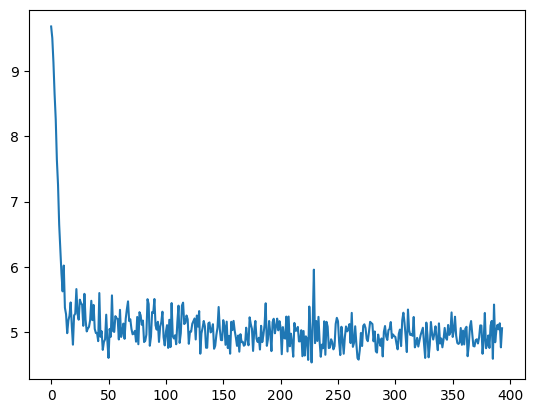

In [28]:
try:
    loss = word2vec.trainer.loss
    plt.plot(loss['train.batch']), plt.show()
except:
    traceback.print_exc()

In [30]:
try:
    core.key_cached('cached', lambda: word2vec, group='Midnight._prepare_embedder')
except:
    traceback.print_exc()

In [31]:
try:
    with torch.no_grad():
        print(word2vec(torch.tensor([midnight.tokenize_text('love')])))
except:
    traceback.print_exc()

tensor([[[ 2.1630, -6.8972, -6.8958,  ..., -6.9237, -6.9265, -6.9269]]])


In [ ]:
try:
    pass
except:
    traceback.print_exc()

In [ ]:
try:
    pass
except:
    traceback.print_exc()

In [ ]:
try:
    pass
except:
    traceback.print_exc()

In [ ]:
try:
    pass
except:
    traceback.print_exc()